# 05. Análisis de resultados

Trabaja **directamente desde `results/experiments_master.csv`**, pensado para correrse en una sesión nueva, después de que `04_run_experiments.ipynb` ya guardó y cerró (o incluso en otra máquina). Nada de esto depende de tener los objetos `NestedCVResult` en memoria: las columnas `"{metrica}_per_fold"` y `"best_params_per_fold"` que `nested_cv.py` persiste alcanzan para reconstruir todo lo necesario.

Contenido: tabla de métricas, comparación estadística jerárquica (Friedman → Nemenyi → CD diagram → DeLong → Cliff's Delta), matriz de confusión/curva ROC del mejor modelo, calibración (+ recalibración si corresponde), y complejidad computacional (estándar vs. optimizado).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from src import config
from src.data_loader import load_processed_dataset, split_features_target
from src.synthetic_data import generate_synthetic_dataset
from src.preprocessing import remove_duplicate_rows
from src.models import MODEL_REGISTRY
from src.experiment_runner import load_master_table
from src.evaluation import (
    format_metrics_table,
    regenerate_outof_fold_predictions,
    evaluate_calibration,
    is_calibration_poor,
    assess_and_recalibrate,
)
from src.complexity_analysis import compare_standard_vs_optimized, TRAIN_INFERENCE_COMPLEXITY
from src import stats_comparison as sc

np.random.seed(config.RANDOM_STATE)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Cargar datos y tabla maestra

**Importante:** debe ser el MISMO dataset (mismas filas, mismo orden) usado en `04_run_experiments.ipynb`; se necesita para reconstruir los folds exactos (`complexity_analysis.recover_outer_fold`) al regenerar predicciones para DeLong/matriz de confusión/calibración/complejidad.

In [2]:
try:
    df = load_processed_dataset()
except FileNotFoundError:
    df = generate_synthetic_dataset()
df, _ = remove_duplicate_rows(df)
X, y = split_features_target(df)

table = load_master_table(config.EXPERIMENTS_MASTER_PATH)
if table.empty:
    raise RuntimeError("La tabla maestra está vacía. Correr primero 04_run_experiments.ipynb.")
print(f"{len(table)} combinaciones en la tabla maestra.")

5 combinaciones en la tabla maestra.


## Tabla de métricas (media ± desviación estándar, outer loop)

In [3]:
metric_for_ranking = config.DEFAULT_SCORING
table_sorted = table.sort_values(f"{metric_for_ranking}_mean", ascending=False)
format_metrics_table(table_sorted)

,model,technique,method,accuracy,precision,recall,f1,roc_auc
3,decision_tree,none,random_search,0.8552 ± 0.0121,0.6894 ± 0.0213,0.6447 ± 0.0444,0.6661 ± 0.0335,0.8513 ± 0.0117
4,decision_tree,class_weight,random_search,0.8194 ± 0.0063,0.5706 ± 0.0098,0.7916 ± 0.0184,0.6632 ± 0.0126,0.8647 ± 0.0131
1,logistic_regression,none,random_search,0.8628 ± 0.0098,0.7685 ± 0.027,0.5565 ± 0.03,0.6454 ± 0.0285,0.8609 ± 0.0067
2,logistic_regression,class_weight,random_search,0.7886 ± 0.0099,0.52 ± 0.0154,0.789 ± 0.0081,0.6266 ± 0.0086,0.8623 ± 0.0029
0,naive_bayes,none,random_search,0.7982 ± 0.0056,0.5433 ± 0.0138,0.65 ± 0.0287,0.5912 ± 0.0045,0.8113 ± 0.0058


## Cobertura de la grilla: 112 combinaciones teóricas

7 modelos × 4 técnicas de balanceo × 4 métodos de optimización = 112 combinaciones teóricas. De esas, 8 no son aplicables porque KNN y Naive Bayes no aceptan `class_weight` en scikit-learn (`KNeighborsClassifier` y `GaussianNB` no tienen ese parámetro; ver `src/models.py` y `src/balancing.py`). Quedan 104 combinaciones corridas realmente. La tabla siguiente muestra las 112 filas para que la cobertura quede documentada explícitamente, en vez de simplemente omitir las 8 no aplicables.

In [ ]:
import pandas as pd
from src.balancing import BALANCING_TECHNIQUES, is_compatible
from src.optimization import OPTIMIZATION_METHODS

filas_teoricas = [
    (model_name, technique, method, is_compatible(spec, technique))
    for model_name, spec in MODEL_REGISTRY.items()
    for technique in BALANCING_TECHNIQUES
    for method in OPTIMIZATION_METHODS
]
reporte_112 = pd.DataFrame(filas_teoricas, columns=["model", "technique", "method", "compatible"])
reporte_112 = reporte_112.merge(
    table[["model", "technique", "method", f"{metric_for_ranking}_mean"]],
    on=["model", "technique", "method"], how="left",
)
reporte_112["estado"] = np.where(
    ~reporte_112["compatible"],
    "No aplica (sklearn no admite class_weight para este modelo)",
    np.where(reporte_112[f"{metric_for_ranking}_mean"].notna(), "Corrida", "Pendiente"),
)

print(f"Total de combinaciones teóricas: {len(reporte_112)}")
print(reporte_112["estado"].value_counts().to_string())
reporte_112.drop(columns="compatible").sort_values(["estado", "model", "technique", "method"])

## Comparación estadística jerárquica

Friedman (ómnibus) → solo si es significativo: Nemenyi + CD diagram + DeLong (top 2-3, con corrección Holm) + Cliff's Delta. Ver `stats_comparison.py` para la justificación completa de por qué es jerárquico y la limitación honesta de potencia estadística con pocos folds externos.

In [4]:
comparison = sc.run_hierarchical_comparison_from_table(
    table, X, y, metric=metric_for_ranking, top_k_for_delong=3
)

friedman = comparison["friedman"]
print(
    f"Friedman: estadístico={friedman['statistic']:.4f}, p={friedman['p_value']:.4f}, "
    f"significativo={friedman['significant']} (alpha={friedman['alpha']}, "
    f"{friedman['n_blocks']} folds, {friedman['k_combinations']} combinaciones)"
)
friedman["avg_ranks"]

Friedman: estadístico=8.8000, p=0.0663, significativo=False (alpha=0.05, 3 folds, 5 combinaciones)


decision_tree|none|random_search                  1.666667
decision_tree|class_weight|random_search          2.000000
logistic_regression|none|random_search            2.666667
logistic_regression|class_weight|random_search    3.666667
naive_bayes|none|random_search                    5.000000
dtype: float64

In [5]:
if comparison["friedman"]["significant"]:
    sc.plot_cd_diagram(
        comparison["friedman"]["avg_ranks"],
        comparison["nemenyi_p_matrix"],
        cd=comparison["critical_difference"],
        save_path=str(config.FIGURES_DIR / "cd_diagram.png"),
    )
    print(f"Diferencia Crítica (CD): {comparison['critical_difference']:.4f}")
    print(f"Top-{len(comparison['top_combos'])} para DeLong: {comparison['top_combos']}")
    print("\nDeLong (pares dentro del top, corrección Holm):")
    display(comparison["delong_comparisons"])
    print("\nCliff's Delta (tamaño del efecto, ver limitación de N_OUTER_FOLDS pequeño en el docstring):")
    display(comparison["cliffs_delta"])
else:
    print(comparison["stage_2_note"])

Friedman no significativo (p=0.0663 >= alpha=0.05): no se reporta evidencia de superioridad de ninguna combinación. Dado que N_OUTER_FOLDS=3 (pocos bloques), esto puede reflejar falta de potencia estadística tanto como equivalencia real — ver limitación documentada en el docstring del módulo.


## Mejor combinación: matriz de confusión y curva ROC

Predicciones out-of-fold **regeneradas** desde `best_params_per_fold` (ya conocidos, un `fit` por fold, no una búsqueda de hiperparámetros nueva) vía `evaluation.regenerate_outof_fold_predictions`.

Mejor combinación según f1: decision_tree | none | random_search


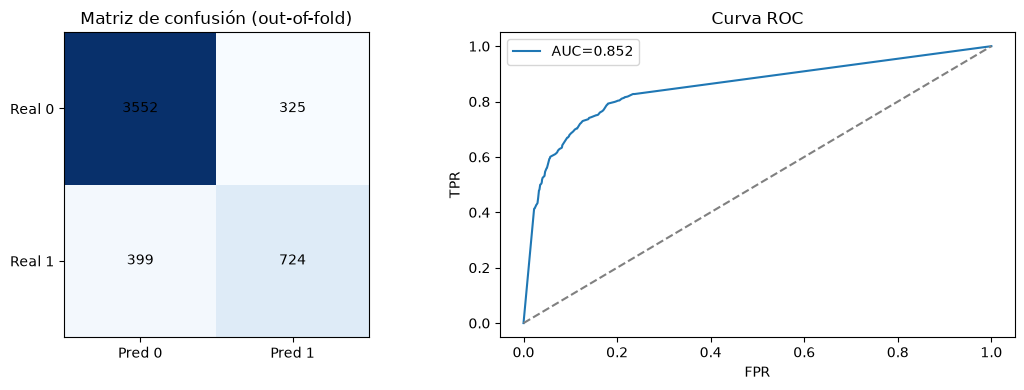

In [6]:
best_row = table.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
best_model = best_row["model"]
best_technique = best_row["technique"]
best_method = best_row["method"]
best_params_per_fold = json.loads(best_row["best_params_per_fold"])
print(f"Mejor combinación según {metric_for_ranking}: {best_model} | {best_technique} | {best_method}")

y_true_best, y_pred_best, y_proba_best = regenerate_outof_fold_predictions(
    MODEL_REGISTRY[best_model],
    best_technique,
    best_params_per_fold,
    X,
    y,
    n_outer_folds=int(best_row["n_outer_folds"]),
    random_state=int(best_row["random_state"]),
)

cm = confusion_matrix(y_true_best, y_pred_best, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_true_best, y_proba_best)
auc = roc_auc_score(y_true_best, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha="center", va="center")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred 0", "Pred 1"]); axes[0].set_yticklabels(["Real 0", "Real 1"])
axes[0].set_title("Matriz de confusión (out-of-fold)")

axes[1].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("Curva ROC")
axes[1].legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / f"confusion_roc_{best_model}.png", dpi=150, bbox_inches="tight")
plt.show()

## Calibración: Brier, ECE, reliability diagram (+ recalibración si corresponde)

Brier: 0.1147  ECE: 0.0878  (calibración deficiente: True)


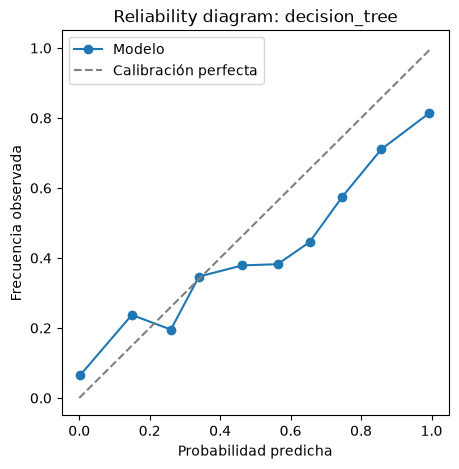

Recalibración (isotonic, fold 2): ECE 0.0998 -> 0.0223 (mejora Brier: 0.0100)


In [7]:
calib = evaluate_calibration(y_true_best, y_proba_best, n_bins=10)
print(
    f"Brier: {calib['brier_score']:.4f}  ECE: {calib['ece']:.4f}  "
    f"(calibración deficiente: {is_calibration_poor(calib['ece'])})"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(calib["reliability_curve"]["prob_pred"], calib["reliability_curve"]["prob_true"], marker="o", label="Modelo")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Frecuencia observada")
ax.set_title(f"Reliability diagram: {best_model}"); ax.legend()
plt.savefig(config.FIGURES_DIR / f"reliability_{best_model}.png", dpi=150, bbox_inches="tight")
plt.show()

per_fold_metric = json.loads(best_row[f"{metric_for_ranking}_per_fold"])
best_fold_idx = int(np.argmax(per_fold_metric))

if is_calibration_poor(calib["ece"]):
    recal = assess_and_recalibrate(
        MODEL_REGISTRY[best_model],
        best_technique,
        best_params_per_fold[best_fold_idx],
        X,
        y,
        best_fold_idx,
        method="isotonic",
        n_outer_folds=int(best_row["n_outer_folds"]),
    )
    print(
        f"Recalibración (isotonic, fold {best_fold_idx}): "
        f"ECE {recal['before']['ece']:.4f} -> {recal['after']['ece']:.4f} "
        f"(mejora Brier: {recal['brier_improvement']:.4f})"
    )
else:
    print("Calibración adecuada, no se aplica recalibración.")

## Complejidad computacional: estándar vs. optimizado

In [8]:
complexity_row = compare_standard_vs_optimized(
    MODEL_REGISTRY[best_model],
    best_technique,
    best_params_per_fold[best_fold_idx],
    X,
    y,
    best_fold_idx,
    n_outer_folds=int(best_row["n_outer_folds"]),
    scoring=metric_for_ranking,
)

print(f"Complejidad teórica ({best_model}):")
print(f"  Train:      {TRAIN_INFERENCE_COMPLEXITY[best_model]['train']}")
print(f"  Inferencia: {TRAIN_INFERENCE_COMPLEXITY[best_model]['inference']}")

import pandas as pd

pd.DataFrame([complexity_row])[
    [
        "standard_fit_time_seconds",
        "optimized_fit_time_seconds",
        "standard_fit_peak_memory_mb",
        "optimized_fit_peak_memory_mb",
        f"standard_{metric_for_ranking}",
        f"optimized_{metric_for_ranking}",
        "performance_change",
    ]
]

Complejidad teórica (decision_tree):
  Train:      O(n·p·log n) en promedio (ordenar features para evaluar cada split).
  Inferencia: O(log n) por consulta en promedio (profundidad del árbol).


,standard_fit_time_seconds,optimized_fit_time_seconds,standard_fit_peak_memory_mb,optimized_fit_peak_memory_mb,standard_f1,optimized_f1,performance_change
0,0.057769,0.064309,1.428141,1.417515,0.668421,0.71159,0.043169


Continuar en `06_interpretability.ipynb` para SHAP/LIME del mejor modelo.